In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
np.random.seed(42)
#we are ignoring warnings because they can distract attention
#random seed is 42 for reproducibility

In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\gciha\Desktop\heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
columns = ['age','anaemia','creatinine_phosphokinase','diabetes','efection_fraction','high_blood_pressure','platelets','serum_creatinine','serum_sodium','sex','smoking','time','DEATH_EVENT']
print(df.shape)
print(df.head())
"""
-age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- creatinine phosphokinase  (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction  (percentage)
- high blood pressure: if the patient has hypertension (boolean)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- [target] death event: if the patient died during the follow-up period (boolean)
"""


(299, 13)
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1 

'\n-age: age of the patient (years)\n- anaemia: decrease of red blood cells or hemoglobin (boolean)\n- creatinine phosphokinase  (CPK): level of the CPK enzyme in the blood (mcg/L)\n- diabetes: if the patient has diabetes (boolean)\n- ejection fraction: percentage of blood leaving the heart at each contraction  (percentage)\n- high blood pressure: if the patient has hypertension (boolean)\n- platelets: platelets in the blood (kiloplatelets/mL)\n- sex: woman or man (binary)\n- serum creatinine: level of serum creatinine in the blood (mg/dL)\n- serum sodium: level of serum sodium in the blood (mEq/L)\n- smoking: if the patient smokes or not (boolean)\n- time: follow-up period (days)\n- [target] death event: if the patient died during the follow-up period (boolean)\n'

In [4]:
#299 rows and 13 key features in the dataaset: including clinical attributes and target outcomr

In [5]:
for column in df.columns:
    print(column)
#extracting the attributes that we'll work with
#Outcome is the label (death_event)

age
anaemia
creatinine_phosphokinase
diabetes
ejection_fraction
high_blood_pressure
platelets
serum_creatinine
serum_sodium
sex
smoking
time
DEATH_EVENT


In [6]:
#check for missing values
df.isnull().sum()
#no missing values :) Now we can analyze the spread of the data for a better understanding

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [7]:
print(df.describe()) #for key statistics

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

In [8]:
#in order to build a reliable model, we should focus on potential issues like 0 values where they are invalid
# 0 insulin, blood pressure is impossible but we dont have these features in our dataset

In [9]:
#Relationships between features help to understand underlying patterns and risk factors

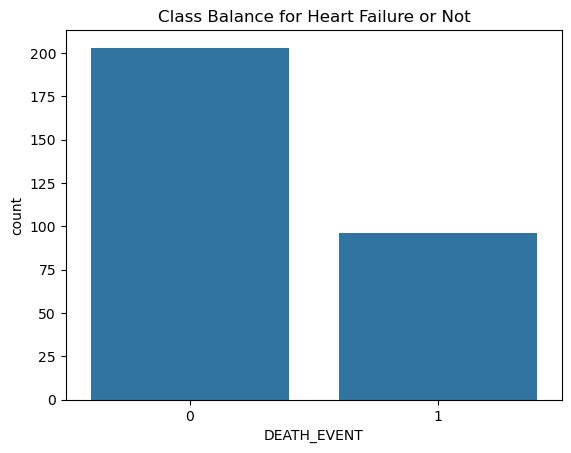

In [10]:
#check class balances, how many death events occured ?
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='DEATH_EVENT', data=df)
plt.title('Class Balance for Heart Failure or Not')
plt.show()

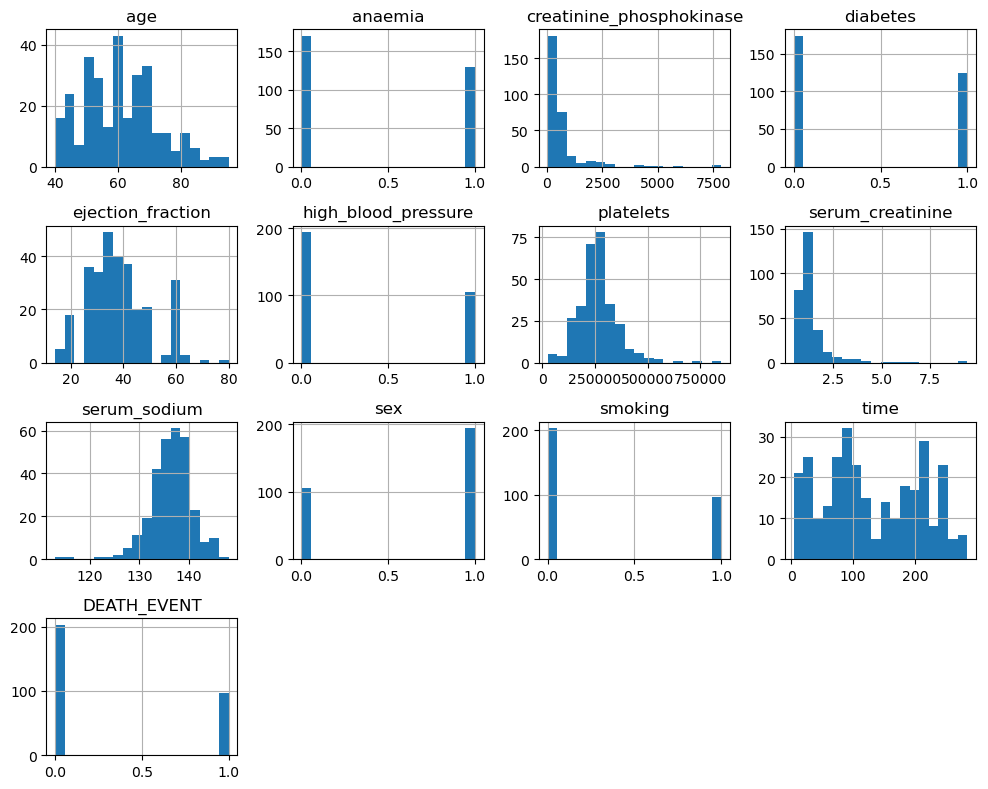

In [11]:
#histogram shows the spread of data 
#bin size: rule of thumb is square root of the sample size: 299^(1/2) = 17.29
import matplotlib.pyplot as plt
df.hist(bins =18 , figsize = (10,8))
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Heart Failure by age')

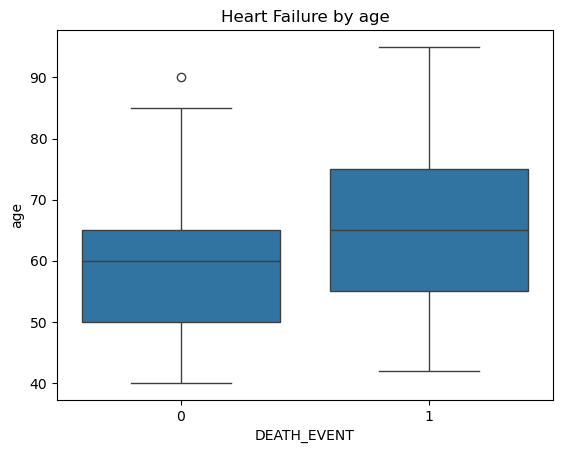

In [12]:
#box plots show if a feature separates  the two classes
#anaemia, high blood pressure and diabetes may increase the risk of heart failure
import seaborn as sns
sns.boxplot(data=df, x='DEATH_EVENT', y='age')
plt.title('Heart Failure by age')

In [13]:
#Now we are ready to set up features and labels for predictive modelling
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']
print(X.shape, y.shape)

(299, 12) (299,)


In [14]:
#To check if your model can predict new patients, split your data into training and test sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)
#Our model can learn patterns most data while being evaluated on unseen examples/samples.

(239, 12) (60, 12)


In [15]:
#We will use logistic reression is used for binary problems
from sklearn.linear_model import LogisticRegression
model= LogisticRegression(max_iter=500, solver='lbfgs')
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [16]:
#Now, we'll see how well our model works with new data
#Accuracy is measured (fraction of true predictions)
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.80


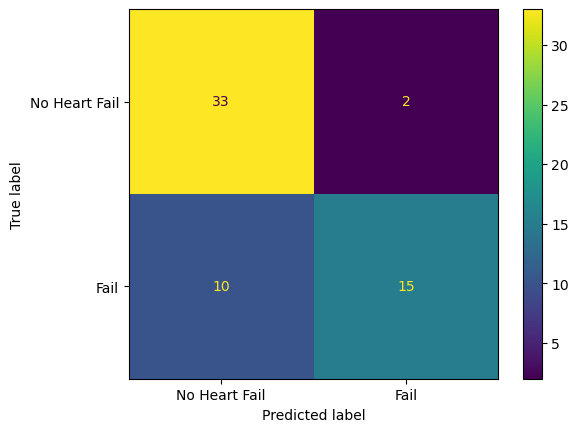

In [17]:
#Confusion matrix to detect false negatives and false positives
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(conf,display_labels = ['No Heart Fail', 'Fail'])
display.plot()
plt.show()


In [21]:
#Which features are the most influencing variables on heart failure?
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([('scaler', StandardScaler()),('logreg', LogisticRegression(max_iter=500))])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# we are trying to access the coefficients through the named step in the pipeline
coef = model.named_steps['logreg'].coef_[0]  
for name, value in zip(X.columns, coef):
    print(f'{name}:{value:.2f}')

age:0.66
anaemia:-0.05
creatinine_phosphokinase:0.11
diabetes:0.16
ejection_fraction:-0.88
high_blood_pressure:-0.06
platelets:-0.17
serum_creatinine:0.70
serum_sodium:-0.26
sex:-0.36
smoking:0.07
time:-1.65


In [ ]:
#Ready to try our model with new patient inputs
user_input = []
for i in X.columns:
    # we are using the built-in input() function to get user input
    values = float(input(f'Enter {i}: '))
    user_input.append(values)

# Use the collected input in the prediction
prediction = model.predict([user_input])[0]
if prediction == 1:
    print('Prediction Heart failure')
else:
    print('Prediction No Heart failure')
